In [ ]:
!pip install statsmodels pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats
import joblib
import os
import json

In [ ]:
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)
print(os.getcwd())

/content


In [ ]:
df = pd.read_csv(
    "btcusd_1-min_data.csv",
    names=["timestamp", "open", "high", "low", "close", "volume"],
    header=0
)
print(f"Raw data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.tail(3))

Raw data shape: (7476160, 6)
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume']
            timestamp     open     high      low    close    volume
7476157  1.774051e+09  70495.0  70511.0  70495.0  70511.0  0.196376
7476158  1.774051e+09  70502.0  70505.0  70502.0  70502.0  0.558047
7476159  1.774051e+09  70498.0  70515.0  70498.0  70515.0  0.601561


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")
df = df.dropna(subset=["timestamp"])
df = df.set_index("timestamp")
df = df.sort_index()
print(f"Date range (raw): {df.index.min()} → {df.index.max()}")

Date range (raw): 2012-01-01 10:01:00 → 2026-03-21 00:00:00


###Resampling Data to Hourly Basis

In [ ]:
df_hourly = df.resample("1h").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
})
print(df_hourly.tail(3))
print(f"Hourly shape (full history): {df_hourly.shape}")

                        open     high      low    close      volume
timestamp                                                          
2026-03-20 22:00:00  70529.0  70899.0  70528.0  70765.0  110.513008
2026-03-20 23:00:00  70759.0  70761.0  70424.0  70502.0   78.591778
2026-03-21 00:00:00  70498.0  70515.0  70498.0  70515.0    0.601561
Hourly shape (full history): (124623, 5)


###Crop the data from 2020 - present

In [ ]:
df_hourly = df_hourly["2020-01-01":]

print(f"Hourly shape (2020-present): {df_hourly.shape}")
print(f"Date range: {df_hourly.index.min()} → {df_hourly.index.max()}")
print(df_hourly.head(3))

Hourly shape (2020-present): (54505, 5)
Date range: 2020-01-01 00:00:00 → 2026-03-21 00:00:00
                        open     high      low    close     volume
timestamp                                                         
2020-01-01 00:00:00  7145.05  7157.28  7129.55  7146.74  47.275357
2020-01-01 01:00:00  7142.02  7161.21  7137.00  7148.02  76.426240
2020-01-01 02:00:00  7144.52  7160.99  7139.39  7160.99  55.671254


In [ ]:
df_hourly = df_hourly.dropna(subset=["open", "high", "low", "close", "volume"], axis=0)
print(f"After dropping NaN rows: {df_hourly.shape}")

After dropping NaN rows: (54487, 5)


In [ ]:
def stationarity_test(series, name):
    # ADF Test: H0 = non-stationary, want p < 0.05 to reject
    adf_stat, adf_p, _, _, _, _ = adfuller(series.dropna())

    # KPSS Test: H0 = stationary, want p > 0.05 to not reject
    kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c')

    print(f"\n{'─'*40}")
    print(f"Series: {name}")
    print(f"ADF  → stat: {adf_stat:.4f}, p-value: {adf_p:.4f} {'✅ Stationary' if adf_p < 0.05 else '❌ Non-Stationary'}")
    print(f"KPSS → stat: {kpss_stat:.4f}, p-value: {kpss_p:.4f} {'✅ Stationary' if kpss_p > 0.05 else '❌ Non-Stationary'}")

stationarity_test(df_hourly["close"],      "Raw Close Price")


────────────────────────────────────────
Series: Raw Close Price
ADF  → stat: -1.3660, p-value: 0.5985 ❌ Non-Stationary
KPSS → stat: 25.4489, p-value: 0.0100 ❌ Non-Stationary


/tmp/ipykernel_3539/1942173409.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c')


In [ ]:
df_stationary_ARIMA = df_hourly.copy()
df_stationary_ARIMA["log_return"] = np.log(df_stationary_ARIMA["close"]/df_stationary_ARIMA["close"].shift(1))
df_stationary_ARIMA = df_stationary_ARIMA.drop(columns=["open", "high", "low", "close", "volume"])
df_stationary_ARIMA = df_stationary_ARIMA.dropna()
print(f"df_hourly   shape : {df_hourly.shape}   ← raw OHLCV, non-stationary")
print(f"df_stationary shape: {df_stationary_ARIMA.shape} ← log returns, stationary")
print(f"\ndf_stationary columns: {df_stationary_ARIMA.columns.tolist()}")
print(f"\nSample:\n{df_stationary_ARIMA.head(5)}")

df_hourly   shape : (54487, 5)   ← raw OHLCV, non-stationary
df_stationary shape: (54486, 1) ← log returns, stationary

df_stationary columns: ['log_return']

Sample:
                     log_return
timestamp                      
2020-01-01 01:00:00    0.000179
2020-01-01 02:00:00    0.001813
2020-01-01 03:00:00    0.001443
2020-01-01 04:00:00   -0.000414
2020-01-01 05:00:00   -0.002565


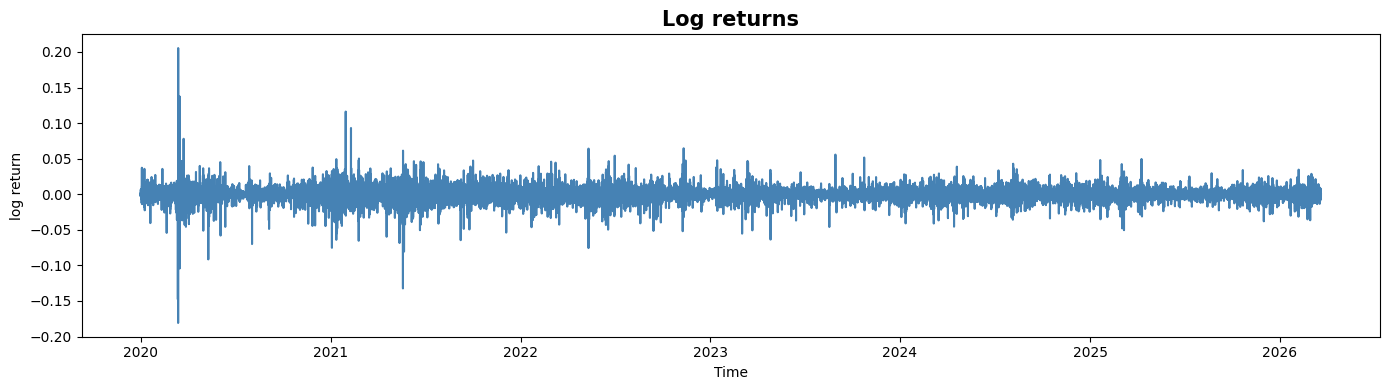

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_stationary_ARIMA.index, df_stationary_ARIMA['log_return'], color='steelblue', linewidth=1.5)
ax.set_title('Log returns', fontsize=15, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('log return')
plt.tight_layout()
plt.savefig('figures/01_log_returns.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df_non_stationary_ARIMA = df_hourly.copy()
df_non_stationary_ARIMA = df_non_stationary_ARIMA.drop(columns=["open", "high", "low", "volume"])
df_non_stationary_ARIMA = df_non_stationary_ARIMA.dropna()
print(f"df_hourly   shape : {df_hourly.shape}   ← raw OHLCV, non-stationary")
print(f"df_non_stationary shape: {df_non_stationary_ARIMA.shape}")
print(f"\ndf_non_stationary columns: {df_non_stationary_ARIMA.columns.tolist()}")
print(f"\nSample:\n{df_non_stationary_ARIMA.head(5)}")

df_hourly   shape : (54487, 5)   ← raw OHLCV, non-stationary
df_non_stationary shape: (54487, 1)

df_non_stationary columns: ['close']

Sample:
                       close
timestamp                   
2020-01-01 00:00:00  7146.74
2020-01-01 01:00:00  7148.02
2020-01-01 02:00:00  7160.99
2020-01-01 03:00:00  7171.33
2020-01-01 04:00:00  7168.36


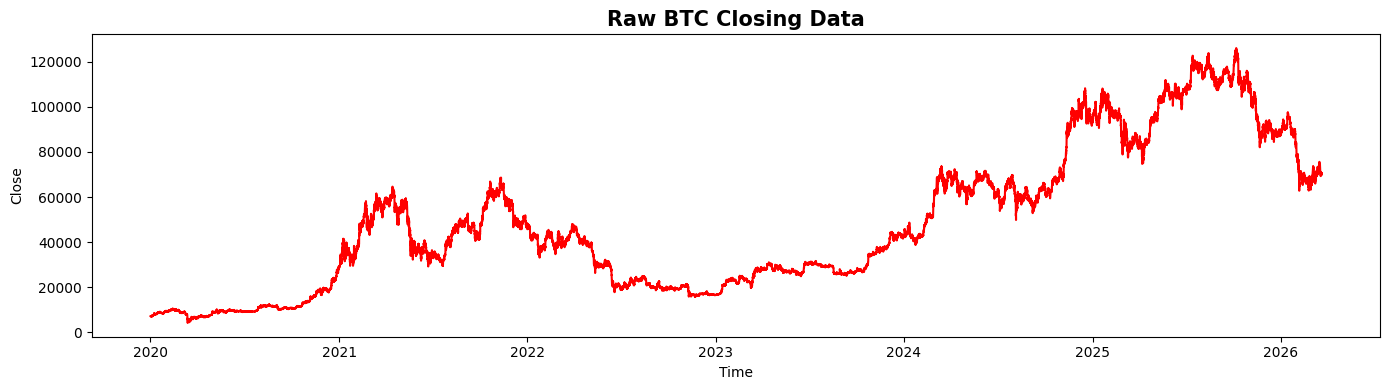

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_non_stationary_ARIMA.index, df_non_stationary_ARIMA['close'], color='red', linewidth=1.5)
ax.set_title('Raw BTC Closing Data', fontsize=15, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Close')
plt.tight_layout()
plt.savefig('figures/02_btc_raw_price.png', dpi=150, bbox_inches='tight')
plt.show()

###Seasonal Decomposition
For a period of 24 hours i.e. daily no seasonal pattern is found.

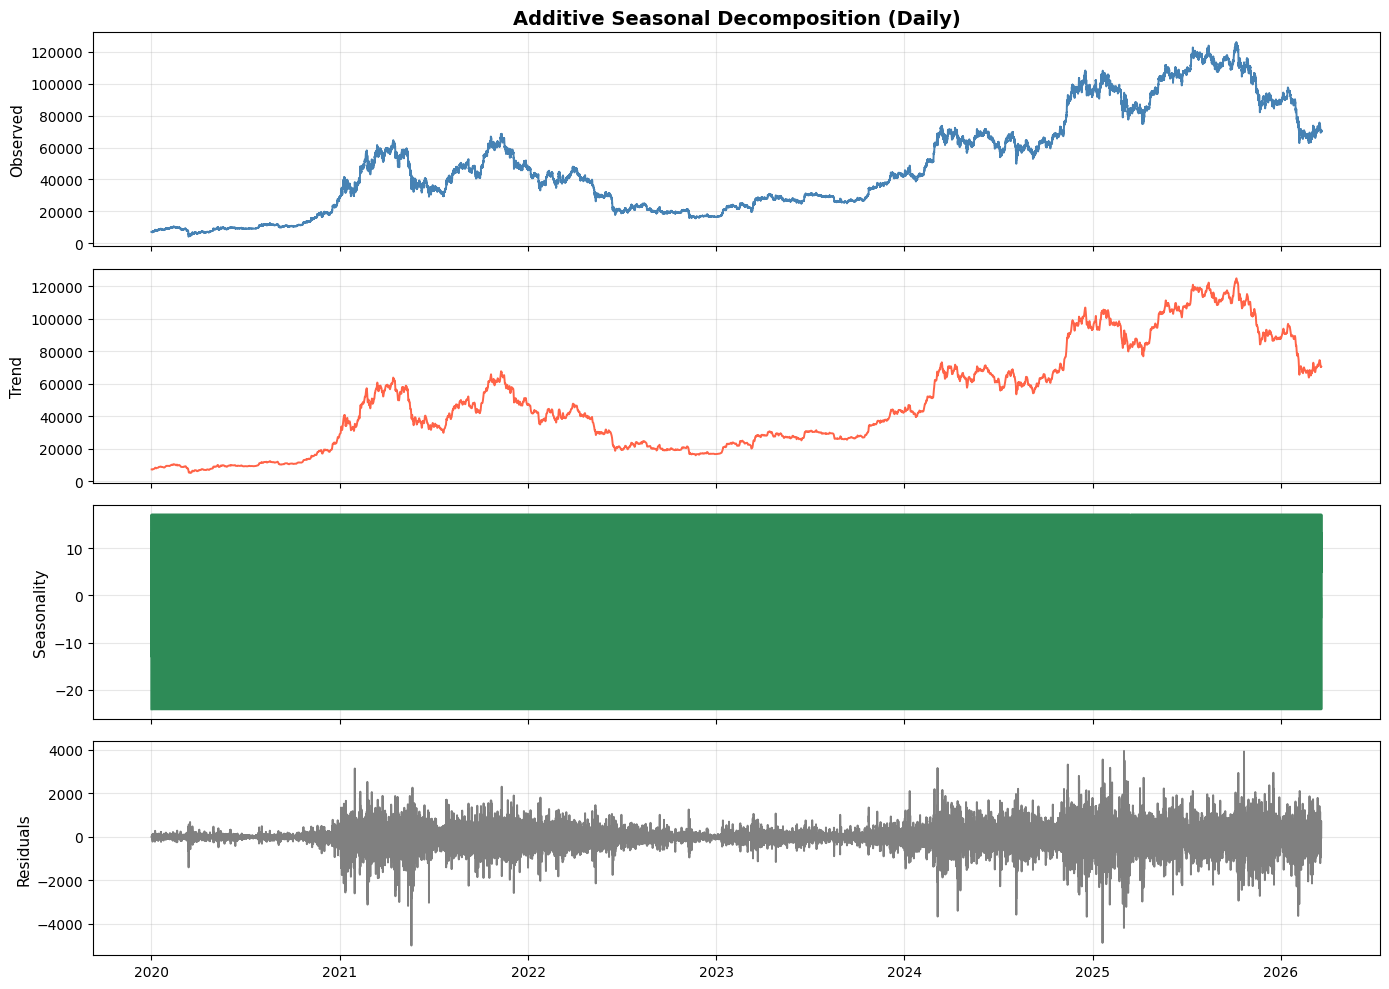

In [ ]:
decomp = seasonal_decompose(df_non_stationary_ARIMA['close'], model='additive', period=24)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
titles = ['Observed', 'Trend', 'Seasonality', 'Residuals']
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
colors = ['steelblue', 'tomato', 'seagreen', 'gray']

for ax, title, comp, color in zip(axes, titles, components, colors):
    ax.plot(comp, color=color, linewidth=1.4)
    ax.set_ylabel(title, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Additive Seasonal Decomposition (Daily)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_seasonal_decomp_daily.png', dpi=150, bbox_inches='tight')
plt.show()

So we change the period to yearly to observe some seasonal patterns

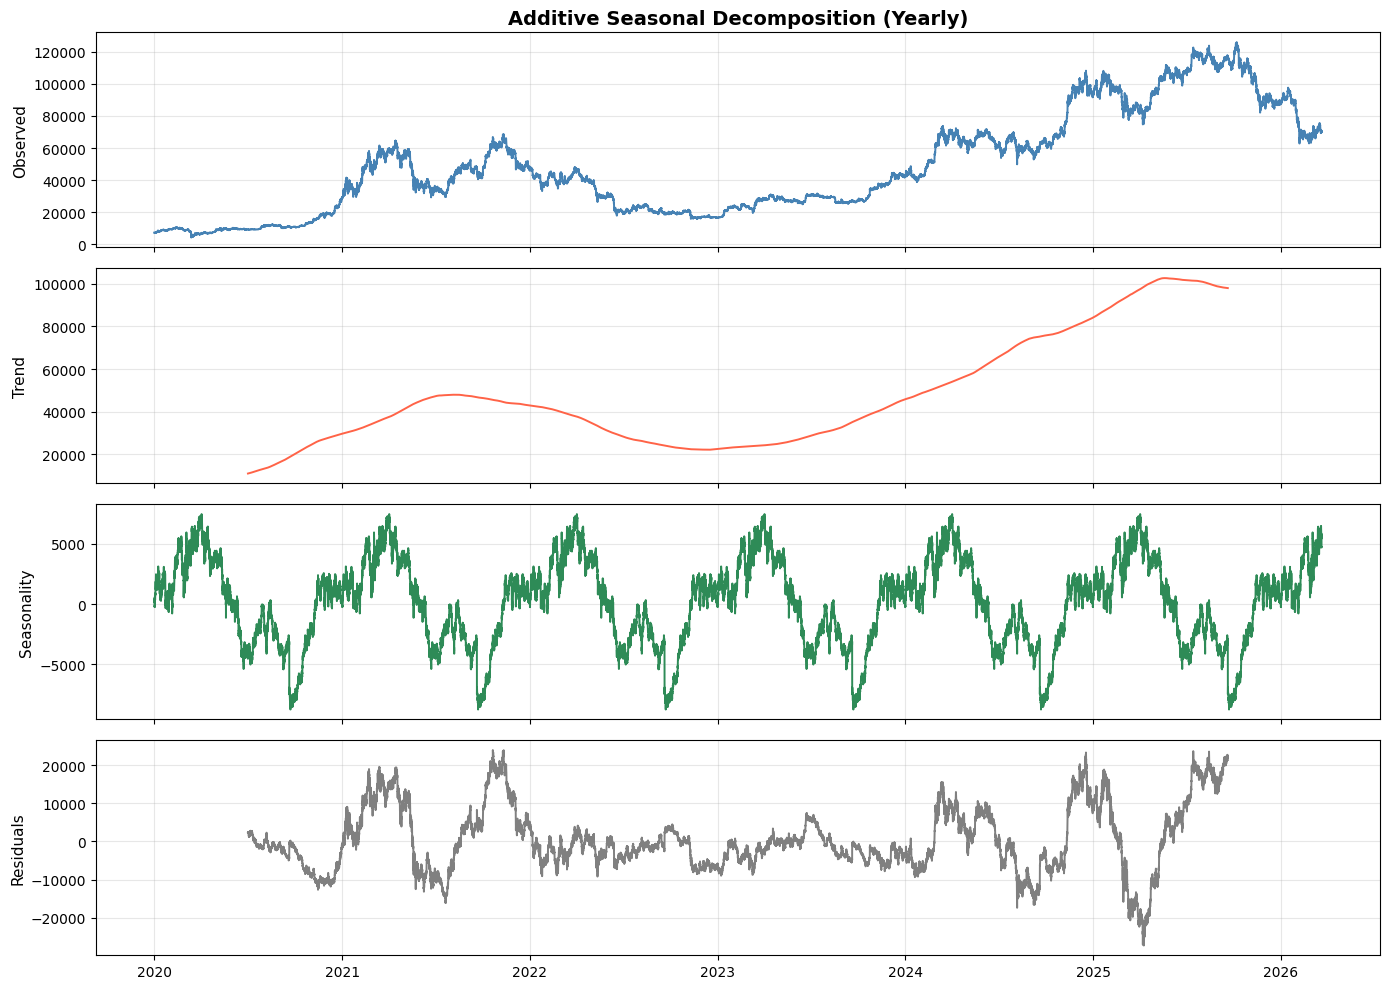

In [ ]:
decomp = seasonal_decompose(df_non_stationary_ARIMA['close'], model='additive', period=8760)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
titles = ['Observed', 'Trend', 'Seasonality', 'Residuals']
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
colors = ['steelblue', 'tomato', 'seagreen', 'gray']

for ax, title, comp, color in zip(axes, titles, components, colors):
    ax.plot(comp, color=color, linewidth=1.4)
    ax.set_ylabel(title, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Additive Seasonal Decomposition (Yearly)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/04_seasonal_decomp_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
stationarity_test(df_stationary_ARIMA["log_return"], "Log Returns")
stationarity_test(df_non_stationary_ARIMA["close"], "Raw Closing Price")

/tmp/ipykernel_3539/1942173409.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c')



────────────────────────────────────────
Series: Log Returns
ADF  → stat: -32.4662, p-value: 0.0000 ✅ Stationary
KPSS → stat: 0.2059, p-value: 0.1000 ✅ Stationary

────────────────────────────────────────
Series: Raw Closing Price
ADF  → stat: -1.3660, p-value: 0.5985 ❌ Non-Stationary
KPSS → stat: 25.4489, p-value: 0.0100 ❌ Non-Stationary


/tmp/ipykernel_3539/1942173409.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c')


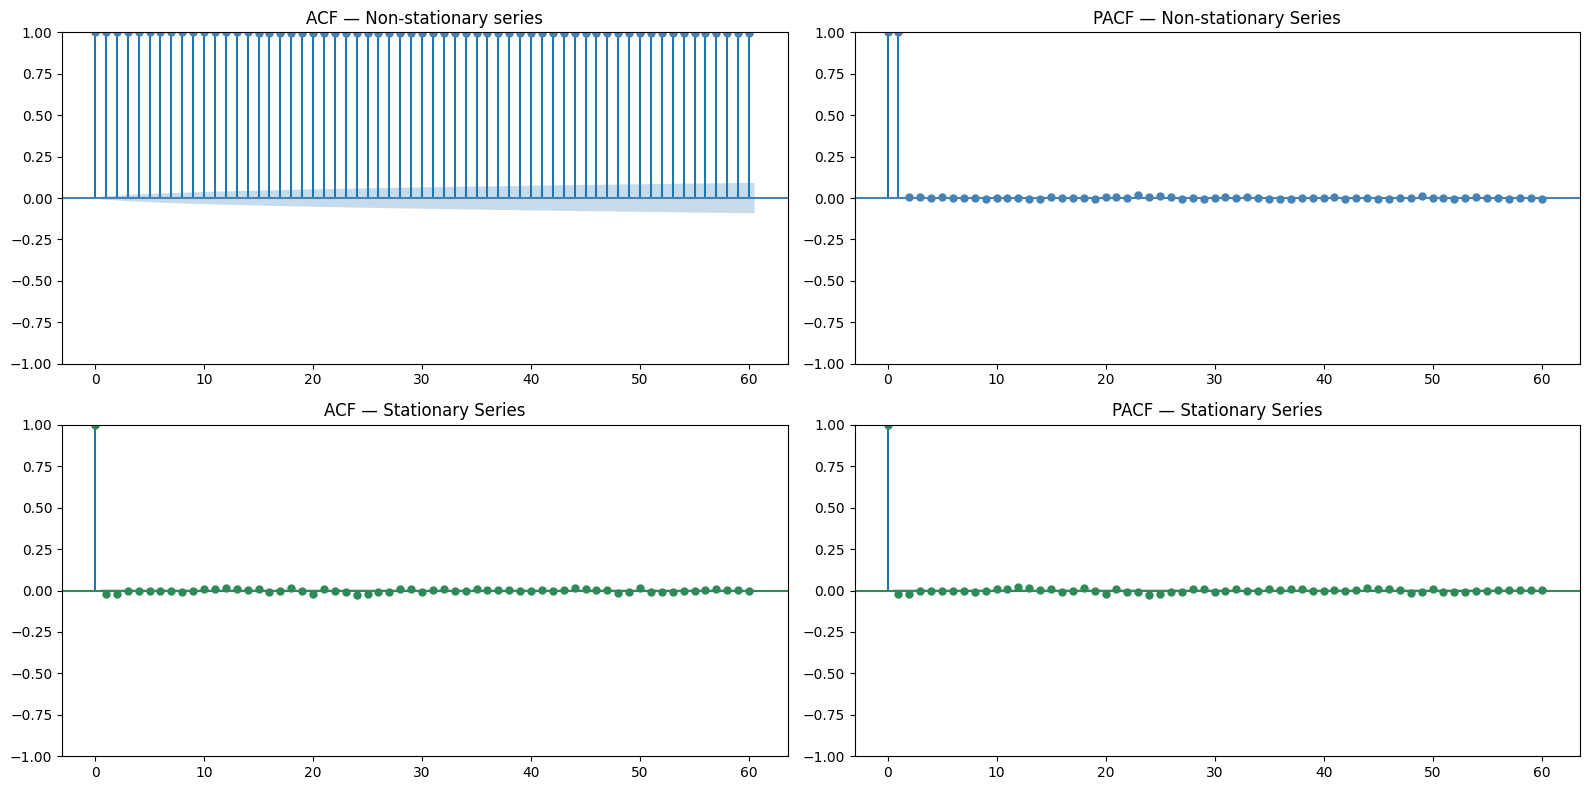

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plot_acf(df_non_stationary_ARIMA['close'], lags=60, ax=axes[0][0], color='steelblue')
axes[0][0].set_title('ACF — Non-stationary series')

plot_pacf(df_non_stationary_ARIMA['close'], lags=60, ax=axes[0][1], color='steelblue')
axes[0][1].set_title('PACF — Non-stationary Series')

plot_acf(df_stationary_ARIMA["log_return"], lags=60, ax=axes[1][0], color='seagreen')
axes[1][0].set_title('ACF — Stationary Series')

plot_pacf(df_stationary_ARIMA["log_return"], lags=60, ax=axes[1][1], color='seagreen')
axes[1][1].set_title('PACF — Stationary Series')

plt.tight_layout()
plt.savefig('figures/05_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

Train data shape: (43589, 1)
Test data shape:  (10898, 1)


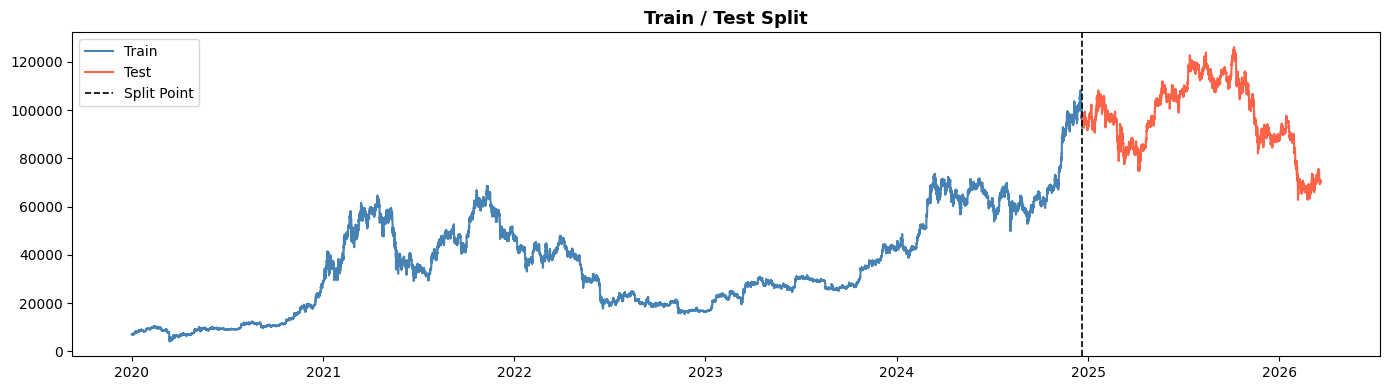

In [ ]:
# 80/20 split
train_size_non_stationary = int(len(df_non_stationary_ARIMA) * 0.8)
train_data_non_stationary = df_non_stationary_ARIMA[:train_size_non_stationary]
test_data_non_stationary = df_non_stationary_ARIMA[train_size_non_stationary:]

print(f"Train data shape: {train_data_non_stationary.shape}")
print(f"Test data shape:  {test_data_non_stationary.shape}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_data_non_stationary, label='Train', color='steelblue')
ax.plot(test_data_non_stationary,  label='Test',  color='tomato')
ax.axvline(train_data_non_stationary.index[-1], color='black', linestyle='--', linewidth=1.2, label='Split Point')
ax.set_title('Train / Test Split', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/06_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
auto_model_non_stationary = auto_arima(
    train_data_non_stationary["close"],
    d=None,
    seasonal=False,
    max_p=5, max_q=3,
    stepwise=True,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)
print(f"\n✅ Best Order      : {auto_model_non_stationary.order}")
print(f"✅ Best Seasonal   : {auto_model_non_stationary.seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=613140.505, Time=39.66 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=613153.826, Time=1.58 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=613151.301, Time=2.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=613151.161, Time=2.95 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=613154.317, Time=0.46 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=613144.756, Time=5.48 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=613143.609, Time=7.72 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=613141.983, Time=44.34 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=613143.026, Time=11.77 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=613147.482, Time=14.95 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=613146.280, Time=8.31 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=613146.930, Time=5.54 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=613138.337, Time=41.46 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=613128.912, Time=20.61 sec

Train data shape: (43588, 1)
Test data shape:  (10898, 1)


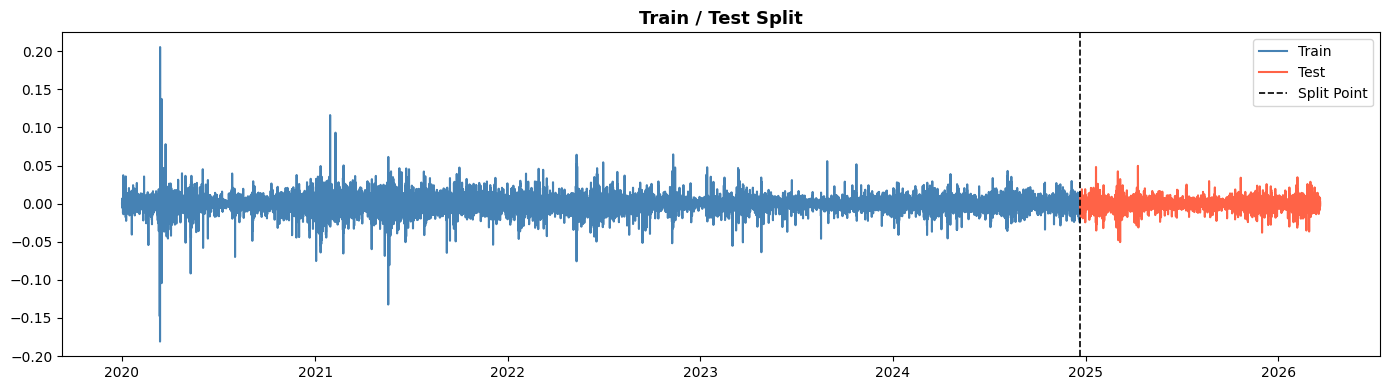

In [ ]:
# 80/20 split
train_size_stationary = int(len(df_stationary_ARIMA) * 0.8)
train_data_stationary = df_stationary_ARIMA[:train_size_stationary]
test_data_stationary = df_stationary_ARIMA[train_size_stationary:]

print(f"Train data shape: {train_data_stationary.shape}")
print(f"Test data shape:  {test_data_stationary.shape}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_data_stationary, label='Train', color='steelblue')
ax.plot(test_data_stationary,  label='Test',  color='tomato')
ax.axvline(train_data_stationary.index[-1], color='black', linestyle='--', linewidth=1.2, label='Split Point')
ax.set_title('Train / Test Split', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/06b_train_test_split_stationary.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
auto_model_stationary = auto_arima(
    train_data_stationary["log_return"],
    d=0,
    seasonal=False,
    max_p=5, max_q=3,
    stepwise=True,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)
print(f"\n✅ Best Order      : {auto_model_stationary.order}")
print(f"✅ Best Seasonal   : {auto_model_stationary.seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-307138.437, Time=4.89 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-307093.613, Time=2.15 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-307119.797, Time=2.72 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-307121.035, Time=3.17 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-307137.490, Time=3.51 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-307136.814, Time=6.43 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-307133.220, Time=11.87 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-307135.308, Time=6.82 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-307138.604, Time=9.64 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-307138.573, Time=4.30 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-307137.910, Time=6.63 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-307140.092, Time=21.21 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-307122.278, Time=5.75 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-307121.030, Tim

Our experiment demonstrates the implications of violating stationarity. The non-stationary model (4,1,2) over-complicates the relationship, attempting to 'chase' the trend with high-order lags. Conversely, the stationary model (1,0,1) identifies a much more parsimonious and theoretically sound relationship. This proves that preprocessing via log-returns doesn't just make the math easier—it prevents the model from being 'distracted' by the non-stationary trend, leading to a more generalized baseline

In [ ]:
arima_model_non_stationary = ARIMA(
    train_data_non_stationary["close"],
    order=auto_model_non_stationary.order,
    seasonal_order=auto_model_non_stationary.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()
print(arima_model_non_stationary.summary())
arima_model_non_stationary.save('models/arima_model_non_stationary.pkl')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                43589
Model:                 ARIMA(4, 1, 2)   Log Likelihood             -306530.787
Date:                Sun, 22 Mar 2026   AIC                         613075.575
Time:                        09:20:22   BIC                         613136.352
Sample:                    01-01-2020   HQIC                        613094.735
                         - 12-21-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1143      0.109      1.053      0.292      -0.098       0.327
ar.L2         -0.1925      0.104     -1.844      0.065      -0.397       0.012
ar.L3          0.0033      0.003      1.057      0.2

In [ ]:
arima_model_stationary = ARIMA(
    train_data_stationary["log_return"],
    order=auto_model_stationary.order,
    seasonal_order=auto_model_stationary.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()
print(arima_model_stationary.summary())
arima_model_stationary.save('models/arima_model_stationary.pkl')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                43588
Model:                 ARIMA(1, 0, 1)   Log Likelihood              153565.865
Date:                Sun, 22 Mar 2026   AIC                        -307123.730
Time:                        09:20:34   BIC                        -307089.000
Sample:                    01-01-2020   HQIC                       -307112.781
                         - 12-21-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.952e-05   3.34e-05      1.784      0.074   -5.88e-06       0.000
ar.L1          0.5323      0.039     13.820      0.000       0.457       0.608
ma.L1         -0.5585      0.038    -14.853      0.0

In [ ]:
def evaluate(actual, forecast, model_name, scale="price"):
    mae  = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    decimals = 6 if scale == "return" else 2

    print(f"\n  {model_name} Model Evaluation")
    print(f"  {'─'*38}")
    print(f"  MAE  : {mae:.{decimals}f}")
    print(f"  RMSE : {rmse:.{decimals}f}")

    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse}

In [ ]:
arima_non_stationary_forecast = arima_model_non_stationary.forecast(len(test_data_non_stationary["close"]))
arima_non_stationary_metrics = evaluate(test_data_non_stationary["close"], arima_non_stationary_forecast, "ARIMA (Non-Stationary)", scale="price")


  ARIMA (Non-Stationary) Model Evaluation
  ──────────────────────────────────────
  MAE  : 12134.42
  RMSE : 14575.85


In [ ]:
arima_stationary_forecast = arima_model_stationary.forecast(len(test_data_stationary["log_return"]))
arima_stationary_metrics = evaluate(test_data_stationary["log_return"], arima_stationary_forecast, "ARIMA (Stationary)", scale="return")


  ARIMA (Stationary) Model Evaluation
  ──────────────────────────────────────
  MAE  : 0.003208
  RMSE : 0.004936


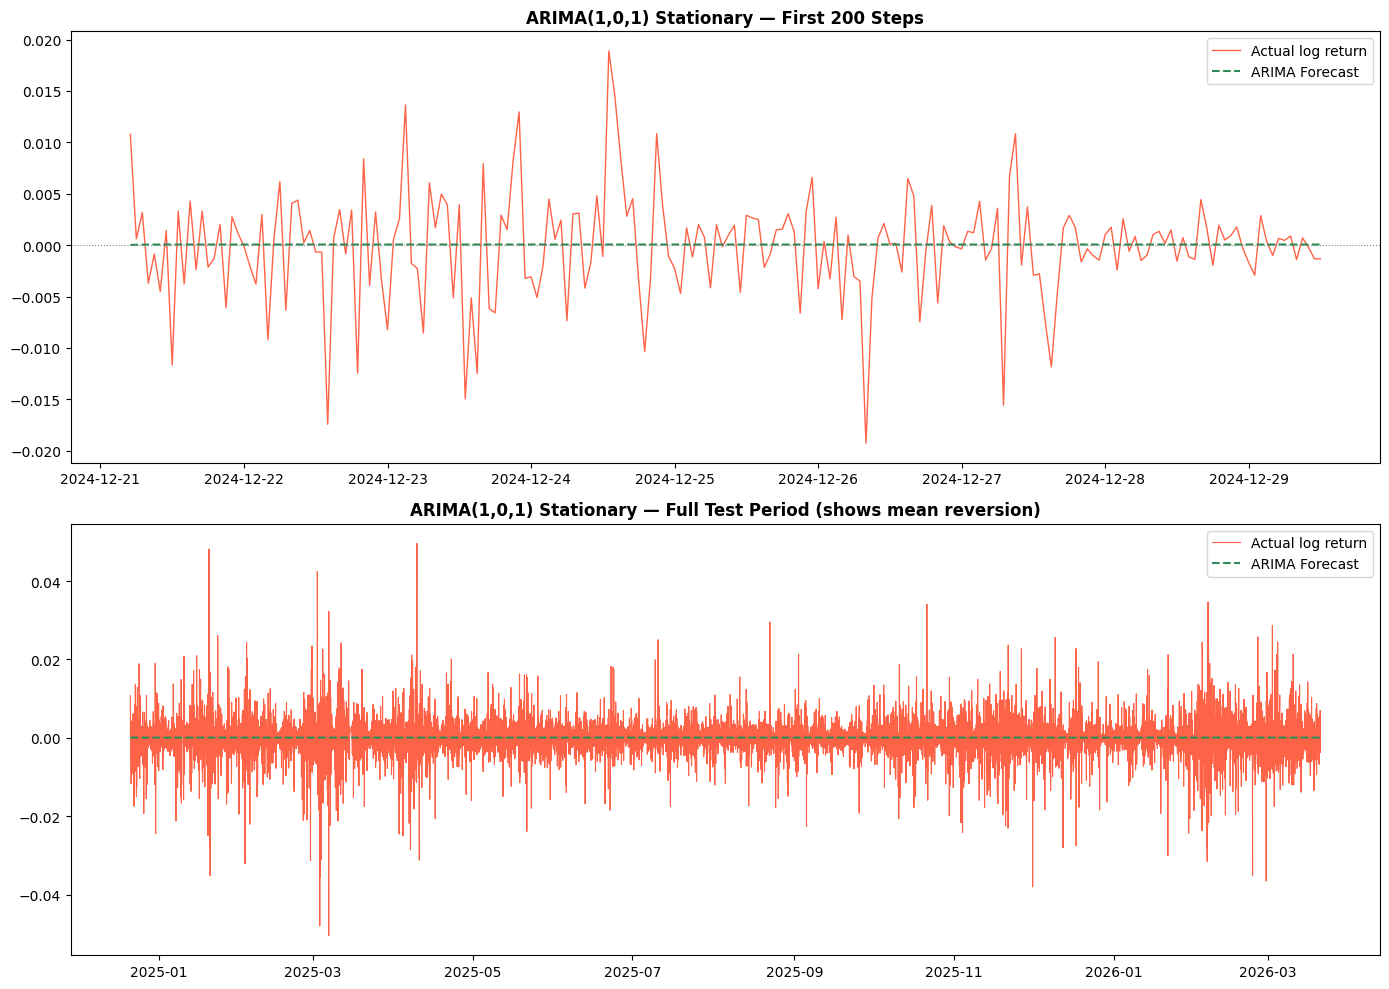

In [ ]:
zoom = 200  # show only first 200 test steps

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: zoomed forecast
axes[0].plot(test_data_stationary.iloc[:zoom],
             label='Actual log return', color='tomato', linewidth=1)
axes[0].plot(test_data_stationary.index[:zoom],
             arima_stationary_forecast[:zoom],
             label='ARIMA Forecast', color='seagreen',
             linestyle='--', linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[0].set_title(f'ARIMA(1,0,1) Stationary — First {zoom} Steps', fontweight='bold')
axes[0].legend()

# Bottom: full test period to show flat-line behavior
axes[1].plot(test_data_stationary,
             label='Actual log return', color='tomato', linewidth=0.8)
axes[1].plot(test_data_stationary.index,
             arima_stationary_forecast,
             label='ARIMA Forecast', color='seagreen',
             linestyle='--', linewidth=1.5)
axes[1].set_title('ARIMA(1,0,1) Stationary — Full Test Period (shows mean reversion)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/07_arima_stationary_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

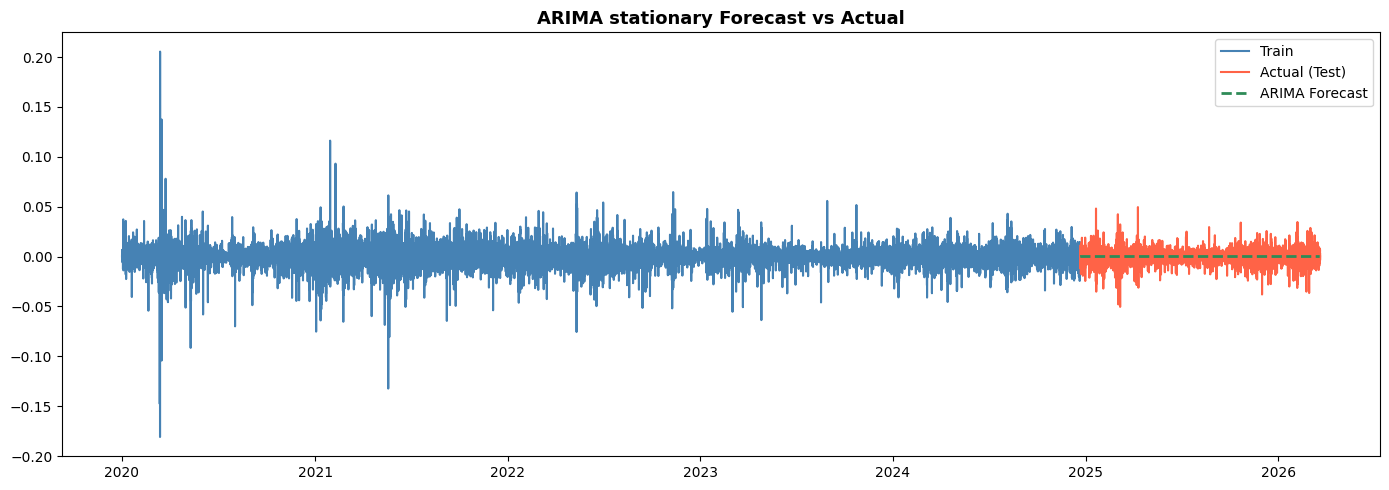

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_data_stationary, label='Train', color='steelblue')
ax.plot(test_data_stationary,  label='Actual (Test)', color='tomato')
ax.plot(arima_stationary_forecast, label='ARIMA Forecast', color='seagreen', linestyle='--', linewidth=2)
ax.set_title('ARIMA stationary Forecast vs Actual', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

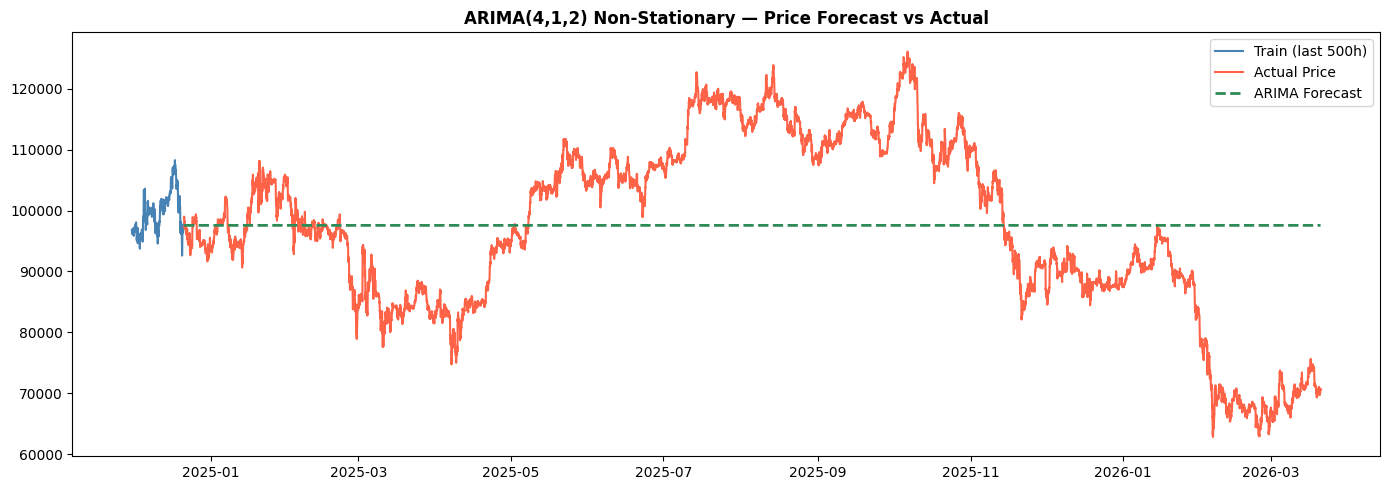

In [ ]:
# ── Non-stationary forecast plot ──
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_data_non_stationary.iloc[-500:],   # last 500 train points for context
        label='Train (last 500h)', color='steelblue')
ax.plot(test_data_non_stationary,
        label='Actual Price', color='tomato')
ax.plot(test_data_non_stationary.index,
        arima_non_stationary_forecast,            # ← fixed variable name
        label='ARIMA Forecast', color='seagreen',
        linestyle='--', linewidth=2)
ax.set_title('ARIMA(4,1,2) Non-Stationary — Price Forecast vs Actual', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/08_arima_nonstationary_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def full_residual_analysis(model, model_name, save_path):
    residuals = model.resid

    print(f"\n{'═'*50}")
    print(f"  Residual Analysis: {model_name}")
    print(f"{'═'*50}")

    # ── 1. Basic stats ──────────────────────────────
    print(f"\n  Mean   : {residuals.mean():.6f}  (want ≈ 0)")
    print(f"  Std    : {residuals.std():.6f}")
    print(f"  Skew   : {residuals.skew():.4f}   (want ≈ 0)")
    print(f"  Kurt   : {residuals.kurtosis():.4f}   (want ≈ 3, excess kurt ≈ 0)")

    # ── 2. Ljung-Box ────────────────────────────────
    lb = acorr_ljungbox(residuals, lags=[10, 20, 40], return_df=True)
    print(f"\n  Ljung-Box Test (H0: residuals are white noise)")
    print(f"  {'Lag':<8} {'p-value':<12} {'Result'}")
    print(f"  {'─'*35}")
    for lag, row in lb.iterrows():
        result = "✅ White noise" if row['lb_pvalue'] > 0.05 else "❌ Autocorrelation remains"
        print(f"  {lag:<8} {row['lb_pvalue']:<12.4f} {result}")

    # ── 3. Jarque-Bera ──────────────────────────────
    jb_stat, jb_p = stats.jarque_bera(residuals)
    print(f"\n  Jarque-Bera Test (H0: residuals are normal)")
    print(f"  p-value: {jb_p:.6f}  {'✅ Normal' if jb_p > 0.05 else '❌ Not Normal (fat tails)'}")

    # ── 4. Plot ─────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Residual Diagnostics — {model_name}', fontsize=14, fontweight='bold')

    axes[0][0].plot(residuals, color='steelblue', linewidth=0.8)
    axes[0][0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0][0].set_title('Residuals over Time')

    axes[0][1].hist(residuals, bins=80, color='steelblue', edgecolor='white')
    axes[0][1].set_title('Residual Distribution')

    plot_acf(residuals, lags=40, ax=axes[1][0], color='seagreen')
    axes[1][0].set_title('ACF of Residuals (want: all inside bands)')

    stats.probplot(residuals, dist="norm", plot=axes[1][1])
    axes[1][1].set_title('QQ Plot (want: points on diagonal)')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')  # ← one file, correct name
    plt.show()


══════════════════════════════════════════════════
  Residual Analysis: ARIMA Stationary (1,0,1)
══════════════════════════════════════════════════

  Mean   : 0.000000  (want ≈ 0)
  Std    : 0.007139
  Skew   : -0.4426   (want ≈ 0)
  Kurt   : 51.6515   (want ≈ 3, excess kurt ≈ 0)

  Ljung-Box Test (H0: residuals are white noise)
  Lag      p-value      Result
  ───────────────────────────────────
  10       0.2206       ✅ White noise
  20       0.0000       ❌ Autocorrelation remains
  40       0.0000       ❌ Autocorrelation remains

  Jarque-Bera Test (H0: residuals are normal)
  p-value: 0.000000  ❌ Not Normal (fat tails)


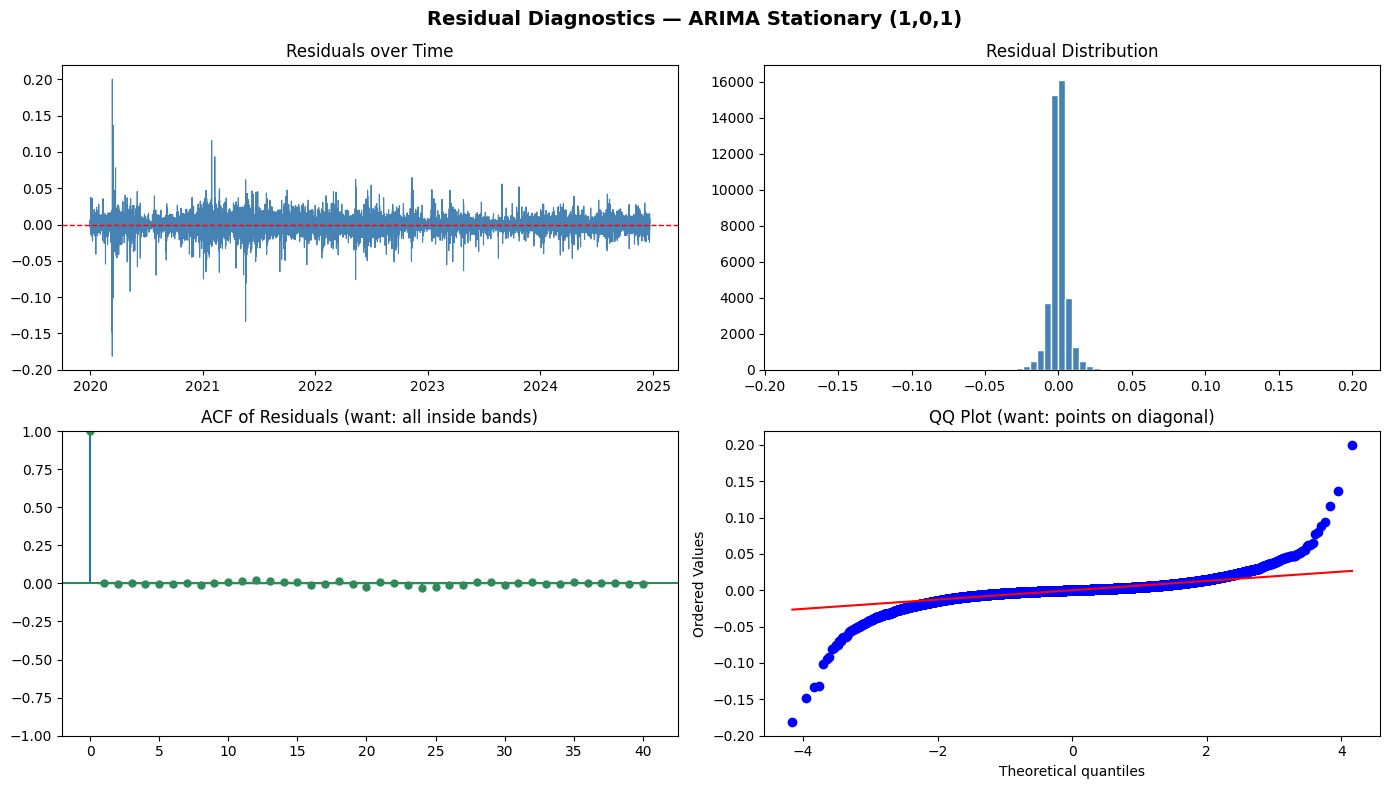


══════════════════════════════════════════════════
  Residual Analysis: ARIMA Non-Stationary (4,1,2)
══════════════════════════════════════════════════

  Mean   : 2.338520  (want ≈ 0)
  Std    : 276.416715
  Skew   : 0.0137   (want ≈ 0)
  Kurt   : 27.9441   (want ≈ 3, excess kurt ≈ 0)

  Ljung-Box Test (H0: residuals are white noise)
  Lag      p-value      Result
  ───────────────────────────────────
  10       0.4024       ✅ White noise
  20       0.0023       ❌ Autocorrelation remains
  40       0.0000       ❌ Autocorrelation remains

  Jarque-Bera Test (H0: residuals are normal)
  p-value: 0.000000  ❌ Not Normal (fat tails)


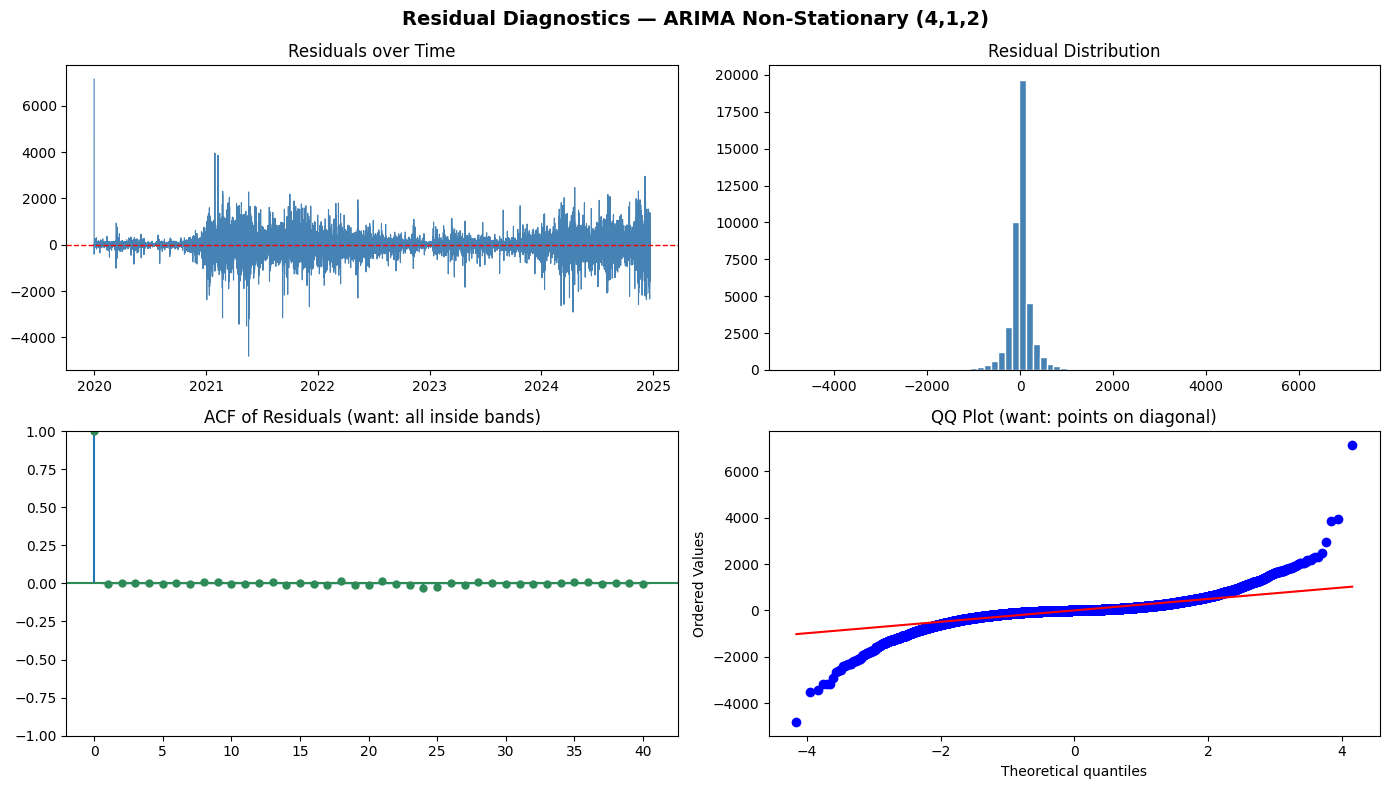

In [ ]:
full_residual_analysis(arima_model_stationary,     "ARIMA Stationary (1,0,1)", "figures/09_residuals_stationary.png")
full_residual_analysis(arima_model_non_stationary, "ARIMA Non-Stationary (4,1,2)", "figures/10_residuals_nonstationary.png")

In [ ]:
metrics = {
    "ARIMA_stationary": {
        "MAE": arima_stationary_metrics["MAE"],
        "RMSE": arima_stationary_metrics["RMSE"]
    },
    "ARIMA_non_stationary": {
        "MAE": arima_non_stationary_metrics["MAE"],
        "RMSE": arima_non_stationary_metrics["RMSE"]
    }
}

with open("models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Metrics saved to models/metrics.json")

✅ Metrics saved to models/metrics.json
